In [237]:
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

def detector_builder(mseq, syndromelength = 5, nphysicalqubits = 8, nrounds = 1, mode = 'binary'):
    if len(mseq) != syndromelength * (nrounds + 1) + nphysicalqubits:
        raise ValueError(f"Measurement sequence length must be equal to syndromelength * nrounds + nphysicalqubits")
    syndromes, finalmeasurement = mseq[:-nphysicalqubits], mseq[-nphysicalqubits:]
    if mode == 'string':
        det = []
        for i in range(nrounds):
            det.append(''.join([str(0 if x == y else 1) for x, y in zip(syndromes[i*syndromelength:(i+1)*syndromelength], syndromes[(i+1)*syndromelength:(i+2)*syndromelength])]))
    elif mode == 'binary':
        det = np.zeros(nrounds * syndromelength, dtype = np.bool)
        for i in range(nrounds):
            det[i*syndromelength:(i+1)*syndromelength] = np.array([0 if x == y else 1 for x, y in zip(syndromes[i*syndromelength:(i+1)*syndromelength], syndromes[(i+1)*syndromelength:(i+2)*syndromelength])])
    else:
        raise ValueError(f"Invalid mode: {mode}")

    return det, finalmeasurement

def check_detector_fired(det):
    for detector in det:
        if '1' in detector:
            return True
    return False

def measure_readout(readout, logical_operator):
    parity = 0
    for i in range(len(readout)):
        if readout[i] == '1' and logical_operator[i]:
            parity += 1
    return parity % 2

xreadoutspace = [
    '00000000', '00001111', '00110011', '00111100', 
    '11000011', '11001100', '11110000', '01010101',
    '10101010', '01011010', '01100110', '01101001',
    '10010110', '10011001', '10100101', '11111111'
]

path = 'sim'
nrounds = [1, 2, 4]
ers = [0.0001, 0.001, 0.01]

In [181]:
#name = 'nopromotion'
#name = 'run0_single_rand0'
name = 'run0_double_rand0'
n, er = 2, 1

In [229]:
def get_text(name):
    txt = os.path.join(path, f'{name}.txt')
    with open(txt, 'r') as f:
        return f.read()
def get_data(name, n, er):
    syndromelength = 6 if 'single' in name else 7
    syndromelength = 5 if 'nopromotion' in name else syndromelength
    width = (nrounds[n] + 1) * syndromelength + 8
    idlequbitfailure = (1 - (1 - 2 * ers[er])**(nrounds[n] * 8)) / 2
    binpath = os.path.join(path, f'{name}_n{n}_er{er}.bin')
    data = np.fromfile(binpath, dtype=[('bits', np.uint64), ('count', np.uint32)])
    bitstrings = [np.binary_repr(row['bits'], width=width) for row in data]
    counts = [row['count'] for row in data]
    #print(len(bitstrings), len(counts))
    return bitstrings, counts, syndromelength, idlequbitfailure

In [187]:
def sim_analysis(bitstrings, counts, syndromelength, idlequbitfailure, logop):
    totalshots = 0
    # s = survived detector postselection, c = correct readout, r = in readout space
    s, c, r, candr, sandr, sandc, sandrandc  = 0, 0, 0, 0, 0, 0, 0
    for i in range(len(bitstrings)):
        bitstring = bitstrings[i]
        count = counts[i]
        totalshots += count
        det, finalmeasurement = detector_builder(bitstring, syndromelength, 8, nrounds[n], mode = 'string')
        inreadoutspace = finalmeasurement in xreadoutspace
        correctreadout = measure_readout(finalmeasurement, logop) == 0
        survives = not check_detector_fired(det)

        if inreadoutspace:
            r += count
        if correctreadout:
            c += count
        if inreadoutspace and correctreadout:
            candr += count
        if survives:
            s += count
            if inreadoutspace:
                sandr += count
            if correctreadout:
                sandc += count
            if inreadoutspace and correctreadout:
                sandrandc += count
    return totalshots, s, r, c, candr, sandr, sandc, sandrandc
    
bitstrings, counts, syndromelength, idlequbitfailure = get_data(name, n, er)
logop = np.array([1, 1, 0, 0, 1, 1, 0, 0])
totalshots, s, r, c, candr, sandr, sandc, sandrandc = sim_analysis(bitstrings, counts, syndromelength, idlequbitfailure, logop)
print(f'Total shots: {totalshots}')
print(f'Survived: {s}')
print(f'In readout space: {r}')
print(f'Correct readout: {c}')
print(f'Correct and in readout space: {candr}')
print(f'Survived and in readout space: {sandr}')
print(f'Survived and correct readout: {sandc}')
print(f'Survived and in readout space and correct readout: {sandrandc}')
print('----------')
print(f'Raw LER: {1 - c / totalshots}, ({totalshots - c} / {totalshots})')
print(f'LER with postsel: {1 - sandc / s}, ({s - sandc} / {s})')
#print(f'LER of only xreadoutspace: {1 - candr / r}, ({r - candr} / {r})')
#print(f'LER with postsel and in xreadoutspace: {1 - sandrandc / sandr}, ({sandr - sandrandc} / {sandr})')
print('----------')
print(f'LER of idle qubit for same clock: {idlequbitfailure}')

6561 6561
Total shots: 1000000
Survived: 990946
In readout space: 993214
Correct readout: 996280
Correct and in readout space: 993214
Survived and in readout space: 990190
Survived and correct readout: 990703
Survived and in readout space and correct readout: 990190
----------
Raw LER: 0.0037199999999999456, (3720 / 1000000)
LER with postsel: 0.00024522022390727205, (243 / 990946)
----------
LER of idle qubit for same clock: 0.0007997200559929363


In [ ]:
# To see the bitstrings and counts in descending order
import copy
data_sorted = copy.deepcopy(data)
data_sorted = sorted(data_sorted, key=lambda row: row['count'], reverse=True)
bitstrings = [np.binary_repr(row['bits'], width=width) for row in data_sorted]
counts = [row['count'] for row in data_sorted]
for i in range(len(bitstrings)):
    print(bitstrings[i], counts[i], *detector_builder(bitstrings[i], syndromelength, 8, nrounds[n], mode = 'string'))

In [232]:
#name = 'nopromotion'
name = 'run0_single_rand0'
#name = 'run0_double_rand0'
info = get_text(name)
print(info)
cLERs = np.zeros((len(nrounds), len(ers)))
numers = np.zeros((len(nrounds), len(ers)))
denoms = np.zeros((len(nrounds), len(ers)))
idles = np.zeros((len(nrounds), len(ers)))
for n in range(len(nrounds)):
    for er in range(len(ers)):
        bitstrings, counts, syndromelength, idlequbitfailure = get_data(name, n, er)
        logop = np.array([1, 1, 0, 0, 1, 1, 0, 0])
        totalshots, s, r, c, candr, sandr, sandc, sandrandc = sim_analysis(bitstrings, counts, syndromelength, idlequbitfailure, logop)
        #print(f'{nrounds[n]} {ers[er]}')
        #print(f'Cond LER = {1 - sandc / s}, ({s - sandc} / {s})')
        cLERs[n, er] = 1 - sandc / s
        numers[n, er] = s - sandc
        denoms[n, er] = s
        idles[n, er] = idlequbitfailure
   

3 969 1000
[[4 3 1 2 0 0 0 0]
 [0 0 0 0 4 1 3 2]
 [1 2 0 0 3 4 0 0]
 [3 0 4 0 1 0 2 0]]
[[0 1 0 4 0 2 0 3]
 [2 0 4 0 1 0 3 0]]
      /-----------------------------------------------------------------------------\ /-----------------------------------------------------------------------------------------------\ /-----------------------------------------------------------------------------------------------\ /-----------------------------------------------------------------------------------------------\ /--------------------------------------------------------------------------------------------------------------\ /-------------------------------------------------------\ /-------------------------------------------------------\ /-------------------------------------------------------\ /----------------------------------------------------------------------------------------------------------------------------------------\
 q0: -R-H-----@-----------------@-@--------------------------X-----

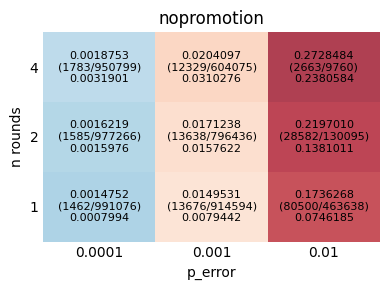

In [ ]:

fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(np.log10(cLERs), aspect='auto', origin='lower', cmap='RdBu_r', vmin = -4, vmax = np.log10(0.5), alpha = 0.8)
for n in range(len(nrounds)):
    for er in range(len(ers)):
        cLER_val = cLERs[n, er]
        text = f"{idles[n, er]:.7f}\n{cLER_val:.7f}\n({numers[n, er]:.0f}/{denoms[n, er]:.0f})\n"
        ax.text(er, n, text, ha='center', va='center', color='black', fontsize=8)
   
ax.set_xlabel('p_error')
ax.set_ylabel('n rounds')
ax.set_title(f'{name}')
ax.set_xticks(np.arange(len(ers)))
ax.set_xticklabels([str(e) for e in ers])
ax.set_yticks(np.arange(len(nrounds)))
ax.set_yticklabels([str(nr) for nr in nrounds])
ax.tick_params(axis='both', which='both', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)  # Hide axis lines
plt.tight_layout()
plt.show()

In [236]:
allnames = ['nopromotion']
for i in range(10):
    for j in range(20):
        allnames.append(f'run{i}_single_rand{j}')
        allnames.append(f'run{i}_double_rand{j}')
print(len(allnames))

401


In [305]:
allnames = ['nopromotion']
for i in range(20):
    allnames.append(f'nopromotion_rand{i}')
print(len(allnames))

21


In [304]:

for name in tqdm(allnames):
    info = get_text(name)
    cLERs = np.zeros((len(nrounds), len(ers)))
    numers = np.zeros((len(nrounds), len(ers)))
    denoms = np.zeros((len(nrounds), len(ers)))
    idles = np.zeros((len(nrounds), len(ers)))
    for n in range(len(nrounds)):
        for er in range(len(ers)):
            bitstrings, counts, syndromelength, idlequbitfailure = get_data(name, n, er)
            logop = np.array([1, 1, 0, 0, 1, 1, 0, 0])
            totalshots, s, r, c, candr, sandr, sandc, sandrandc = sim_analysis(bitstrings, counts, syndromelength, idlequbitfailure, logop)
            cLERs[n, er] = 1 - sandc / s
            numers[n, er] = s - sandc
            denoms[n, er] = s
            idles[n, er] = idlequbitfailure
    fig, ax = plt.subplots(figsize=(4, 3))
    im = ax.imshow(np.log10(cLERs), aspect='auto', origin='lower', cmap='RdBu_r', vmin = -4, vmax = np.log10(0.5), alpha = 0.8)
    for n in range(len(nrounds)):
        for er in range(len(ers)):
            cLER_val = cLERs[n, er]
            text = f"{idles[n, er]:.7f}\n{cLER_val:.7f}\n({numers[n, er]:.0f}/{denoms[n, er]:.0f})\n"
            ax.text(er, n, text, ha='center', va='center', color='black', fontsize=8)
    ax.set_xlabel('p_error')
    ax.set_ylabel('n rounds')
    ax.set_title(f'{name}')
    ax.set_xticks(np.arange(len(ers)))
    ax.set_xticklabels([str(e) for e in ers])
    ax.set_yticks(np.arange(len(nrounds)))
    ax.set_yticklabels([str(nr) for nr in nrounds])
    ax.tick_params(axis='both', which='both', length=0)
    for spine in ax.spines.values():
        spine.set_visible(False) 
    plt.tight_layout()
    plt.savefig(f'imgs/{name}.png')
    stack = np.stack([cLERs, numers, denoms, idles], axis = 0)
    stack.tofile(f'imgs/{name}_stack.bin')
    plt.close()

100%|██████████| 21/21 [02:47<00:00,  7.96s/it]


In [248]:
vals = []
for name in allnames:
    stack = np.fromfile(f'imgs/{name}_stack.bin', dtype = np.float64).reshape(4, len(nrounds), len(ers))
    rel = stack[0, 2, 1]
    vals.append(rel)
vals = np.array(vals)
names = copy.deepcopy(allnames)
#print(vals)


In [249]:
sorted_indices = np.argsort(vals)[::-1]
vals_sorted = vals[sorted_indices]
names_sorted = [names[i] for i in sorted_indices]
for i in range(len(vals_sorted)):
    print(f'{names_sorted[i]} {vals_sorted[i]:.7f}')

nopromotion 0.0204097
run7_single_rand10 0.0126948
run0_single_rand0 0.0122526
run7_single_rand3 0.0120073
run5_single_rand11 0.0119579
run6_single_rand8 0.0114912
run1_single_rand9 0.0114252
run8_single_rand16 0.0112698
run1_single_rand14 0.0112100
run3_double_rand19 0.0111373
run1_single_rand5 0.0110880
run0_single_rand19 0.0108428
run8_single_rand10 0.0106621
run4_double_rand14 0.0105542
run6_double_rand1 0.0104237
run1_single_rand11 0.0103785
run0_single_rand4 0.0103409
run3_single_rand5 0.0102996
run9_single_rand3 0.0101488
run0_single_rand9 0.0101483
run7_single_rand7 0.0101159
run6_single_rand17 0.0101108
run7_single_rand1 0.0100684
run5_single_rand6 0.0100258
run5_double_rand8 0.0097885
run7_double_rand8 0.0097514
run1_single_rand15 0.0097390
run3_double_rand10 0.0096684
run3_single_rand19 0.0096227
run7_single_rand11 0.0094729
run6_double_rand0 0.0094578
run1_single_rand0 0.0094492
run8_single_rand9 0.0094004
run3_single_rand11 0.0093763
run6_single_rand18 0.0093322
run9_singl

In [317]:
#name = 'run2_single_rand0'
#name = 'nopromotion'
name = 'nopromotion_rand8'
stack = np.fromfile(f'imgs/{name}_stack.bin', dtype = np.float64).reshape(4, len(nrounds), len(ers))
rel = stack[0, 2, 1]
print(rel)
info = get_text(name)
print(info)


0.01324660101588726
980 1000
[[3 4 1 2 0 0 0 0]
 [0 0 0 0 2 3 4 1]
 [2 3 0 0 4 1 0 0]
 [4 0 2 0 3 0 1 0]]
[[2 7 8 1 6 4 5 3]]
      /-----------------------------------------------------------------------------\ /-----------------------------------------------------------------------------------------------\ /-----------------------------------------------------------------------------------------------\ /-----------------------------------------------------------------------------------------------\ /--------------------------------------------------------------------------------------------------------------\ /-----------------------------------\ /-----------------------------------\ /-----------------------------------\ /-----------------------------------\ /-----------------------------------\ /-----------------------------------\ /-----------------------------------\ /------------------------------------------------------------------------------------------------------------------